Last edited: 1/28/2026, 3:38 PM CST
# Extreme event return periods as estimated by ERA5 and CMIP models

The idea is to compute return period curves for heat waves in famous locations (Paris, Seattle, Moscow) in the year they had famous heat waves (2003, 2021, 2010).

In [1]:
# import base packages for data analysis
import yaml
import warnings

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

from pathlib import Path

from config import DATA_ROOT
from src.utils import extract_model_name
from src.cmip_dataclass import CMIP6EnsembleConfig
from src.plotting_presets import get_presets

# import custom stuff
from ambpy.plotutils import make_figure_filename

presets, _ = get_presets(markers=False)
plt.rcParams.update(presets)

# set random attributes
np.random.seed(4)

save_figs = True

In [2]:
# Set color and marker sets for CMIP models
# 10 High-Contrast, Colorblind-Friendly Hex Codes (Paul Tol / Okabe-Ito)
colors = ['#4477AA', '#EE6677', '#228833', '#CCBB44', '#66CCEE', 
          '#AA3377', '#EE7733', '#009988', '#332288', '#BBBBBB']

# Marker Set
markers = ['o', 's', 'D'] # Circle, Square, Diamond
linestyles = ['dashed', 'dashdot', 'dotted']

## Step 0: Set Data Attributes for Analysis

In [3]:
return_periods = np.array([
    2, 5, 10, 20, 50, 100, 200, 500, 1e3, 2e3, 5e3, 1e4, 2e4, 5e4, 1e5
])

return_probs = 1 - return_periods**(-1)

In [4]:
# shared attributes
fit = 'nonstat'
anom_type = "raw"

# set anomaly type
if anom_type == 'raw':
    data_type = 'raw'
else:
    data_type = f"anom_{anom_type}"

In [5]:
# attributes of ERA5 data
TMIN = 1979
era5_variable = 't2m_annual_max'

In [6]:
# attributes of CMIP data
cmip_variable = 'tas_annual_max'
CMIPConfig = CMIP6EnsembleConfig.from_yaml(
    'config/meta.yaml',
    'config/qc.yaml'
)

# make file/model matcher for 
data_path = DATA_ROOT / 'CMIP6' / cmip_variable / 'gev'

# Make all landonly file names
fnames = [f for f in data_path.glob(f"*{fit}*{anom_type}*.nc") if "allmems" not in f.name]  # screen out allmems results

modelname_filepath_matcher = {
extract_model_name(f): f for f in fnames
}

## Step 1: Import ERA5 Data, heat wave location info, and Initialize Quantities of Interest for CMIP Comparison

In [7]:
# import ERA5 GEV characteristics
ds_era5 = xr.open_dataset(DATA_ROOT / 'ERA5' / 'gev' / f'era5_{era5_variable}_1deg_landonly_gev_{fit}_TMIN{TMIN}.nc', engine='netcdf4')
PER_DECADE_CONVERSTION_FACTOR = 10 / len(ds_era5.year.values)

# import ERA5 temperatures 
ds_era5_temps = xr.open_dataset(DATA_ROOT / 'ERA5' / f'era5_t2m_annual_mean_1deg.nc')
ds_era5_temps_max = xr.open_dataset(DATA_ROOT / 'ERA5' / f'era5_t2m_annual_max_1deg.nc')

# store flattened, screened numpy arrays of ERA5 fit variables for regressions and bias calculations later
if fit == 'nonstat':
    era5_loc, era5_loc_trend = ds_era5[f'loc_{data_type}'].values.flatten(), ds_era5[f'loc_t_{data_type}'].values.flatten() * PER_DECADE_CONVERSTION_FACTOR
    era5_scale, era5_scale_trend = ds_era5[f'scale_{data_type}'].values.flatten(), ds_era5[f'scale_t_{data_type}'].values.flatten() * PER_DECADE_CONVERSTION_FACTOR
    era5_shape, era5_shape_trend = ds_era5[f'shape_{data_type}'].values.flatten(), ds_era5[f'shape_t_{data_type}'].values.flatten() * PER_DECADE_CONVERSTION_FACTOR

elif fit == 'stat':
    era5_loc, era5_scale, era5_shape = ds_era5[f'loc_{data_type}'].values.flatten(), ds_era5[f'scale_{data_type}'].values.flatten(), ds_era5[f'shape_{data_type}'].values.flatten()

else:
    raise ValueError("Invalid `fit` variable.")

In [8]:
ds_era5_temps_max

<xarray.Dataset>
Dimensions:  (lat: 180, lon: 360, year: 75)
Coordinates:
  * lat      (lat) float64 -89.5 -88.5 -87.5 -86.5 -85.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) int64 0 1 2 3 4 5 6 7 8 ... 352 353 354 355 356 357 358 359
  * year     (year) int64 1950 1951 1952 1953 1954 ... 2020 2021 2022 2023 2024
Data variables:
    t2m      (year, lat, lon) float32 ...

In [9]:
# import event information
EXT_DATA_PATH = Path("config/events_feat.yaml")

with open(EXT_DATA_PATH) as f:
    event_info = yaml.safe_load(f)

N_events = len(event_info.keys())

N_events, event_info

(9,
 {'Seattle': {'lat': 47.61,
   'lon': 237.61,
   'max_T_raw_obs': 42.0,
   'year': 2021},
  'Mexico City': {'lat': 19.43,
   'lon': 260.87,
   'max_T_raw_obs': 34.7,
   'year': 2024},
  'Sao Paulo': {'lat': -23.55,
   'lon': 313.37,
   'max_T_raw_obs': 37.0,
   'year': 2014},
  'Lyon': {'lat': 45.76, 'lon': 4.83, 'max_T_raw_obs': 40.5, 'year': 2003},
  'Lagos': {'lat': 6.45, 'lon': 3.42, 'max_T_raw_obs': 40.1, 'year': 2020},
  'New Delhi': {'lat': 28.61,
   'lon': 77.21,
   'max_T_raw_obs': 49.9,
   'year': 2024},
  'Moscow': {'lat': 55.75, 'lon': 37.62, 'max_T_raw_obs': 38.2, 'year': 2010},
  'Tokyo': {'lat': 35.69, 'lon': 139.69, 'max_T_raw_obs': 39.5, 'year': 2004},
  'Melbourne': {'lat': -37.81,
   'lon': 144.96,
   'max_T_raw_obs': 46.4,
   'year': 2009}})

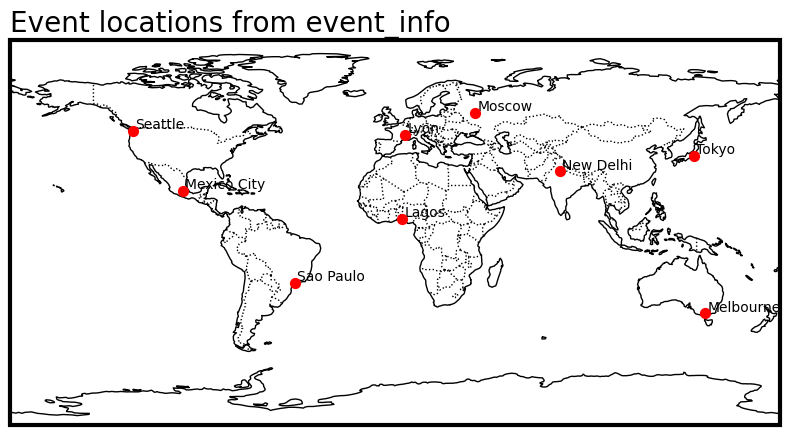

In [10]:
# plot event locations on world map
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# extract lat/lon and adjust longitudes >180
lats = []
lons = []
names = []
for name, info in event_info.items():
    lat = info["lat"]
    lon = info["lon"]
    if lon > 180:
        lon = lon - 360
    lats.append(lat)
    lons.append(lon)
    names.append(name)

fig, ax = plt.subplots(
    figsize=(10, 5),
    subplot_kw={"projection": ccrs.PlateCarree()},
)
ax.set_global()
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=":")
ax.scatter(lons, lats, transform=ccrs.PlateCarree(), color="red", s=50, zorder=5)
for name, lon, lat in zip(names, lons, lats):
    ax.text(lon + 1, lat + 1, name, transform=ccrs.PlateCarree(), fontsize=10)
plt.title("Event locations from event_info")
plt.show()

Setup for primary model member analysis.

In [11]:
# get number of models for this variable
N_active_models = len(
    list(m for m in CMIPConfig.iter_active_models(cmip_variable))
)

return_levels_prim = np.zeros(
    (N_events, N_active_models, len(return_periods))
)

Setup for analyzing the model with the most ensemble members (probably MIROC6 but there can be others).

In [12]:
# Calculate number of ensemble members for each active model
Nens_for_active_models = np.array([
    len(m.all_members) for m in CMIPConfig.iter_active_models(cmip_variable)
])

# Find model(s) with most members
max_inds = np.where(Nens_for_active_models == np.max(Nens_for_active_models))[0]

# Select first model with most members
ind_ = max_inds[0]
model_with_most = [m.name for m in CMIPConfig.iter_active_models(cmip_variable)][ind_]
N_members = np.max(Nens_for_active_models)

return_levels_most = np.zeros(
    (N_events, N_members, len(return_periods))
)

## Step 2: Loop Through CMIP Model with Most Members and Carry Out Fitting

In [13]:
def get_return_level(p, mu, sigma, xi):
    """Computes the return level for an event with probability P
    whose occurance is described by a GEV.

    Parameters
    ----------
    p: float
        probability

    mu: float
        mean-like GEV parameter

    sigma: float
        variance-like GEV parameter

    xi: float
        tail controlling GEV parameter

    Returns
    -------
    ret_level: float
        return level of event with probability p
    """
    
    inside = (-np.log(p))**(-xi) - 1
    ret_level = mu + (sigma / xi) * inside
    return ret_level

def array_max(arr):
    """
    Find the maximum value and its index in an array.

    Parameters:
        arr (array-like): Input array.

    Returns:
        tuple: (max_value, max_index)
    """
    arr = np.asarray(arr)
    max_index = np.argmax(arr)
    max_value = arr[max_index]
    return max_value, int(max_index)

In [14]:
def recenter_model_to_era5(loc_dict, ds_era5, cmip_model_name, member_id, time_interval=slice(1979, 2000)):
    """Recenter CMIP model to ERA5 temperature values.
    """

    # compute ERA5 climatological mean for this location
    era5_clim_mean = ds_era5.sel(lat=loc_dict['lat'],
                                 lon=loc_dict['lon'],
                                 method='nearest').sel(year=time_interval).mean(dim='year').t2m.values

    # compute CMIP climatological mean for this location
    # set data path
    data_path = DATA_ROOT / 'CMIP6' / 'tas_annual_mean' / 'raw'

    # Make all landonly file names
    fnames = [f for f in data_path.glob(f"*{cmip_model_name}_*.nc")]  # screen out allmems results

    # make sure we found a unique file, and then extract the name 
    if len(fnames) == 1:
        cmip_filename = fnames[0]
        # print(f"        Model filename used for recentering: {cmip_filename}")

    else:
        raise ValueError(f"Multiple files found for unique CMIP model {cmip_model_name}. Check which is valid.")

    # import dataset, take mean
    ds_cmip = xr.open_dataset(cmip_filename)
    cmip_clim_mean = ds_cmip.sel(lat=loc_dict['lat'],
                                 lon=loc_dict['lon'],
                                 method='nearest').sel(
                                    year=time_interval, 
                                    member_id=member_id,
                                 ).mean(dim='year').tas.values

    offset = era5_clim_mean - cmip_clim_mean

    # close dataset to save memory
    ds_cmip.close()

    return offset

In [15]:
recenter_model_to_era5(event_info['Seattle'], ds_era5_temps, 'MIROC6', 'MIROC6_r10i1p1f1')  # test centering function

-0.68878174

## ERA5

In [16]:
era5_ret_levels = np.zeros((N_events, len(return_probs)))
era5_max_temp = np.zeros(N_events)
max_temp_year = np.zeros(N_events)

for edx, loc in enumerate(event_info.keys()):
    print(f"⚒️ Working on {loc}...")
    tmp_ds = ds_era5.sel(lat=event_info[loc]['lat'], lon=event_info[loc]['lon'], method='nearest')

    era5_max_temp[edx] = ds_era5_temps_max.sel(lat=event_info[loc]['lat'],
            lon=event_info[loc]['lon'],
            method='nearest').sel(year=event_info[loc]['year']).t2m.values - 274.15

    if fit == 'nonstat':
        era5_loc, era5_loc_trend = tmp_ds[f'loc_{data_type}'].values.flatten(), tmp_ds[f'loc_t_{data_type}'].values.flatten() 
        era5_scale, era5_scale_trend = tmp_ds[f'scale_{data_type}'].values.flatten(), tmp_ds[f'scale_t_{data_type}'].values.flatten() 
        era5_shape, era5_shape_trend = tmp_ds[f'shape_{data_type}'].values.flatten(), tmp_ds[f'shape_t_{data_type}'].values.flatten() 

    elif fit == 'stat':
        era5_loc, era5_scale, era5_shape = ds_era5[f'loc_{data_type}'].values.flatten(), ds_era5[f'scale_{data_type}'].values.flatten(), ds_era5[f'shape_{data_type}'].values.flatten()

    else:
        raise ValueError("Invalid `fit` variable.")

    tmp_loc = era5_loc + era5_loc_trend * (event_info[loc]['year'] - TMIN) / (len(tmp_ds.year.values) - TMIN)
    tmp_scale = era5_scale + era5_scale_trend * (event_info[loc]['year'] - TMIN) / (len(tmp_ds.year.values) - TMIN)
    tmp_shape = era5_shape + era5_shape_trend * (event_info[loc]['year'] - TMIN) / (len(tmp_ds.year.values) - TMIN)

    print(f"    # ERA5 GEV parameters in the event year, {event_info[loc]['year']}: {tmp_loc, tmp_scale, tmp_shape}")

    era5_ret_levels[edx] = get_return_level(return_probs, tmp_loc, tmp_scale, tmp_shape)

    tmp_ds.close()

⚒️ Working on Seattle...
    # ERA5 GEV parameters in the event year, 2021: (array([295.42194791]), array([1.3324078]), array([-0.30221043]))
⚒️ Working on Mexico City...
    # ERA5 GEV parameters in the event year, 2024: (array([291.72394014]), array([0.57581982]), array([-0.0303704]))
⚒️ Working on Sao Paulo...
    # ERA5 GEV parameters in the event year, 2014: (array([298.42427439]), array([0.37798483]), array([-0.07612065]))
⚒️ Working on Lyon...
    # ERA5 GEV parameters in the event year, 2003: (array([297.80967785]), array([0.61245376]), array([0.26511083]))
⚒️ Working on Lagos...
    # ERA5 GEV parameters in the event year, 2020: (array([301.52934311]), array([0.11491474]), array([-0.0419541]))
⚒️ Working on New Delhi...
    # ERA5 GEV parameters in the event year, 2024: (array([310.19547544]), array([0.62987631]), array([0.05200551]))
⚒️ Working on Moscow...
    # ERA5 GEV parameters in the event year, 2010: (array([296.24616028]), array([1.36574281]), array([0.19834786]))
⚒️ 

In [17]:
for loc in event_info.keys():
    diff = ds_era5_temps_max.sel(lat=event_info[loc]['lat'],
            lon=event_info[loc]['lon'],
            method='nearest').sel(year=event_info[loc]['year']).t2m.values - 274.15 - event_info[loc]['max_T_raw_obs']
    print(f"{loc} {diff}")

print(era5_max_temp)


Seattle -13.482733154296852
Mexico City -13.16640624999998
Sao Paulo -10.024999999999977
Lyon -11.436346435546852
Lagos -11.489471435546854
New Delhi -10.886364746093726
Moscow -8.907952880859355
Tokyo -10.215551757812477
Melbourne -13.921215820312476
[28.51726685 21.53359375 26.975      29.06365356 28.61052856 39.01363525
 29.29204712 29.28444824 32.47878418]


## All members of most_mems

In [18]:
# Find all 'allmems' GEV files for the chosen model and anomaly type
gev_dir = DATA_ROOT / 'CMIP6' / cmip_variable / 'gev'
pattern = f"*{model_with_most}*{fit}*allmems*{anom_type}.nc"
allmems_files = sorted(gev_dir.glob(pattern))
print(f"Found {len(allmems_files)} files matching: {pattern}")
for p in allmems_files:
    print(p.name)

# expose the list for later use
allmems_filepaths = allmems_files

Found 1 files matching: *MIROC6*nonstat*allmems*raw.nc
tas_CMIP6_MIROC6_hist+ssp585_1979-2024_landonly_gev_nonstat_allmems_raw.nc


Loop through "most member" model.

In [19]:
# percentiles for masking
plo = 5
phi = 95

MAKE_CHECKS = False

ds = xr.open_dataset(allmems_filepaths[0], engine='netcdf4')

for edx, loc in enumerate(event_info.keys()):
    print(f"\n 🔥 Working on the heat wave in {loc}")

    for idx, mem in enumerate(ds.member_id.values):
        print(f"    ⚒️ Working on member: {mem}")

        # do this for each location
        tmp_ds = ds.sel(member_id=mem)
        tmp_ds = tmp_ds.sel(lat=event_info[loc]['lat'], lon=event_info[loc]['lon'], method='nearest')

        # compute offset of climatatological temps in model vs era5
        offset = recenter_model_to_era5(event_info[loc], ds_era5_temps,
                                        cmip_model_name=model_with_most, member_id=mem)

        # carry out calculations for both nonstationary and stationary cases
        if fit == 'nonstat':
            # extract model variables
            m_loc, m_loc_trend = tmp_ds[f'loc_{data_type}'].values.flatten(), tmp_ds[f'loc_t_{data_type}'].values.flatten() 
            m_scale, m_scale_trend = tmp_ds[f'scale_{data_type}'].values.flatten(), tmp_ds[f'scale_t_{data_type}'].values.flatten() 
            m_shape, m_shape_trend = tmp_ds[f'shape_{data_type}'].values.flatten(), tmp_ds[f'shape_t_{data_type}'].values.flatten() 

            if (np.isnan(m_loc) or np.isnan(m_loc_trend)
                or np.isnan(m_scale) or np.isnan(m_scale_trend)
                or np.isnan(m_shape) or np.isnan(m_shape_trend)):
                warnings.warn(f"Member {mem} skipped for event in {loc} because of nans")
                return_levels_most[edx, idx] = np.array([np.nan] * len(return_probs))

            else:
                tmp_loc = m_loc + m_loc_trend * (event_info[loc]['year'] - TMIN) / (len(tmp_ds.year.values) - TMIN)  # get loc['year'] location parameter
                tmp_scale = m_scale + m_scale_trend * (event_info[loc]['year'] - TMIN) / (len(tmp_ds.year.values) - TMIN)  # get loc['year'] scale parameter
                tmp_shape = m_shape + m_shape_trend * (event_info[loc]['year'] - TMIN) / (len(tmp_ds.year.values) - TMIN)  # get loc['year'] shape parameter

                return_levels_most[edx, idx] = get_return_level(return_probs, tmp_loc, tmp_scale, tmp_shape) + offset

        else:
            import warnings
            warnings.warn("Warning: `stat` not implemented yet or stupid model. Skipping.")

        tmp_ds.close()



 🔥 Working on the heat wave in Seattle
    ⚒️ Working on member: MIROC6_r10i1p1f1
    ⚒️ Working on member: MIROC6_r8i1p1f1
    ⚒️ Working on member: MIROC6_r11i1p1f1
    ⚒️ Working on member: MIROC6_r9i1p1f1
    ⚒️ Working on member: MIROC6_r12i1p1f1
    ⚒️ Working on member: MIROC6_r13i1p1f1
    ⚒️ Working on member: MIROC6_r14i1p1f1
    ⚒️ Working on member: MIROC6_r15i1p1f1
    ⚒️ Working on member: MIROC6_r16i1p1f1
    ⚒️ Working on member: MIROC6_r17i1p1f1
    ⚒️ Working on member: MIROC6_r18i1p1f1
    ⚒️ Working on member: MIROC6_r19i1p1f1
    ⚒️ Working on member: MIROC6_r1i1p1f1
    ⚒️ Working on member: MIROC6_r20i1p1f1
    ⚒️ Working on member: MIROC6_r21i1p1f1
    ⚒️ Working on member: MIROC6_r22i1p1f1
    ⚒️ Working on member: MIROC6_r23i1p1f1
    ⚒️ Working on member: MIROC6_r24i1p1f1
    ⚒️ Working on member: MIROC6_r25i1p1f1
    ⚒️ Working on member: MIROC6_r26i1p1f1
    ⚒️ Working on member: MIROC6_r27i1p1f1
    ⚒️ Working on member: MIROC6_r28i1p1f1
    ⚒️ Working on

/scratch/local/jobs/47619552/ipykernel_1928717/949067437.py:33: UserWarning: Member MIROC6_r32i1p1f1 skipped for event in Sao Paulo because of nans
  warnings.warn(f"Member {mem} skipped for event in {loc} because of nans")


    ⚒️ Working on member: MIROC6_r33i1p1f1
    ⚒️ Working on member: MIROC6_r34i1p1f1
    ⚒️ Working on member: MIROC6_r35i1p1f1
    ⚒️ Working on member: MIROC6_r36i1p1f1
    ⚒️ Working on member: MIROC6_r37i1p1f1
    ⚒️ Working on member: MIROC6_r38i1p1f1
    ⚒️ Working on member: MIROC6_r39i1p1f1
    ⚒️ Working on member: MIROC6_r3i1p1f1
    ⚒️ Working on member: MIROC6_r40i1p1f1
    ⚒️ Working on member: MIROC6_r41i1p1f1
    ⚒️ Working on member: MIROC6_r42i1p1f1
    ⚒️ Working on member: MIROC6_r43i1p1f1
    ⚒️ Working on member: MIROC6_r44i1p1f1
    ⚒️ Working on member: MIROC6_r45i1p1f1
    ⚒️ Working on member: MIROC6_r46i1p1f1
    ⚒️ Working on member: MIROC6_r47i1p1f1
    ⚒️ Working on member: MIROC6_r48i1p1f1
    ⚒️ Working on member: MIROC6_r49i1p1f1
    ⚒️ Working on member: MIROC6_r4i1p1f1
    ⚒️ Working on member: MIROC6_r50i1p1f1
    ⚒️ Working on member: MIROC6_r5i1p1f1
    ⚒️ Working on member: MIROC6_r6i1p1f1
    ⚒️ Working on member: MIROC6_r7i1p1f1

 🔥 Working on t

## Primary members for all CMIP models

In [20]:
# percentiles for masking
plo = 5
phi = 95

# loop through models 
for edx, loc in enumerate(event_info.keys()):
    print(f"\n 🔥 Working on the heat wave in {loc}")
    
    for (idx, m) in enumerate(list(CMIPConfig.iter_active_models(cmip_variable))):
        print(f"    ⚒️ Working on {m.name}...")

        # open dataset
        tmp_ds = xr.open_dataset(
            modelname_filepath_matcher[m.name]
        )

        # do this for each location
        tmp_ds = tmp_ds.sel(lat=event_info[loc]['lat'], lon=event_info[loc]['lon'], method='nearest')

        # compute offset of climatatological temps in model vs era5
        offset = recenter_model_to_era5(event_info[loc], ds_era5_temps,
                                        cmip_model_name=m.name, member_id=m.primary_member)

        # carry out calculations for both nonstationary and stationary cases
        if fit == 'nonstat':
            # extract model variables
            m_loc, m_loc_trend = tmp_ds[f'loc_{data_type}'].values.flatten(), tmp_ds[f'loc_t_{data_type}'].values.flatten() 
            m_scale, m_scale_trend = tmp_ds[f'scale_{data_type}'].values.flatten(), tmp_ds[f'scale_t_{data_type}'].values.flatten() 
            m_shape, m_shape_trend = tmp_ds[f'shape_{data_type}'].values.flatten(), tmp_ds[f'shape_t_{data_type}'].values.flatten() 

            if (np.isnan(m_loc) or np.isnan(m_loc_trend)
                or np.isnan(m_scale) or np.isnan(m_scale_trend)
                or np.isnan(m_shape) or np.isnan(m_shape_trend) or m.name == 'MIROC6'):
                warnings.warn(f"Model {m.name} skipped for event in {loc} because of nans or because it's the MIROC6 model and we already handled its ensemble members")
                return_levels_prim[edx, idx] = np.array([np.nan] * len(return_probs))


            else:
                tmp_loc = m_loc + m_loc_trend * (event_info[loc]['year'] - TMIN) / (len(tmp_ds.year.values) - TMIN)  # get loc['year'] location parameter
                tmp_scale = m_scale + m_scale_trend * (event_info[loc]['year'] - TMIN) / (len(tmp_ds.year.values) - TMIN)  # get loc['year'] scale parameter
                tmp_shape = m_shape + m_shape_trend * (event_info[loc]['year'] - TMIN) / (len(tmp_ds.year.values) - TMIN)  # get loc['year'] shape parameter

                print(f"            # GEV Parameters: {m_loc, m_scale, m_shape}")

                # threshold check on scale parameter 
                if tmp_scale < 1e-2:
                    warnings.warn(f"Model {m.name} skipped for event in {loc} because the scale parameter is unreasonably small")
                    return_levels_prim[edx, idx] = np.array([np.nan] * len(return_probs))

                else:
                    return_levels_prim[edx, idx] = get_return_level(return_probs, tmp_loc, tmp_scale, tmp_shape)

        else:
            import warnings
            warnings.warn("Warning: `stat` not implemented yet or stupid model. Skipping.")

        tmp_ds.close()



 🔥 Working on the heat wave in Seattle
    ⚒️ Working on AWI-CM-1-1-MR...
            # GEV Parameters: (array([294.33665659]), array([1.03940457]), array([0.06582691]))
    ⚒️ Working on BCC-CSM2-MR...
            # GEV Parameters: (array([300.37115555]), array([1.39019755]), array([0.10730147]))
    ⚒️ Working on CAMS-CSM1-0...
            # GEV Parameters: (array([293.50166925]), array([1.07837474]), array([-0.07878249]))
    ⚒️ Working on CESM2-WACCM...
            # GEV Parameters: (array([298.84580721]), array([0.77588001]), array([0.05106734]))
    ⚒️ Working on CMCC-CM2-SR5...
            # GEV Parameters: (array([297.91977515]), array([1.78781235]), array([-0.34584344]))
    ⚒️ Working on CMCC-ESM2...
            # GEV Parameters: (array([297.40230107]), array([2.25065045]), array([-0.25283666]))
    ⚒️ Working on CNRM-CM6-1-HR...
            # GEV Parameters: (array([297.74065516]), array([0.9874816]), array([-0.00291159]))
    ⚒️ Working on CNRM-ESM2-1...
            # GEV 

/scratch/local/jobs/47619552/ipykernel_1928717/3817942207.py:34: UserWarning: Model INM-CM5-0 skipped for event in Seattle because of nans or because it's the MIROC6 model and we already handled its ensemble members
  warnings.warn(f"Model {m.name} skipped for event in {loc} because of nans or because it's the MIROC6 model and we already handled its ensemble members")


    ⚒️ Working on KACE-1-0-G...
            # GEV Parameters: (array([297.81991802]), array([1.81307007]), array([0.03814684]))
    ⚒️ Working on KIOST-ESM...
            # GEV Parameters: (array([293.21486387]), array([1.02662643]), array([-0.04828627]))
    ⚒️ Working on MIROC-ES2L...
            # GEV Parameters: (array([293.95124707]), array([1.38291413]), array([0.13853992]))
    ⚒️ Working on MIROC6...


/scratch/local/jobs/47619552/ipykernel_1928717/3817942207.py:34: UserWarning: Model MIROC6 skipped for event in Seattle because of nans or because it's the MIROC6 model and we already handled its ensemble members
  warnings.warn(f"Model {m.name} skipped for event in {loc} because of nans or because it's the MIROC6 model and we already handled its ensemble members")


    ⚒️ Working on MPI-ESM1-2-HR...
            # GEV Parameters: (array([295.60569131]), array([0.52613853]), array([-1.]))
    ⚒️ Working on MPI-ESM1-2-LR...
            # GEV Parameters: (array([294.53665264]), array([0.75109728]), array([-0.95354107]))
    ⚒️ Working on NorCPM1...
            # GEV Parameters: (array([297.61636018]), array([1.20151048]), array([-0.37777641]))
    ⚒️ Working on NorESM2-LM...
            # GEV Parameters: (array([297.85295736]), array([1.80694171]), array([-0.02780139]))
    ⚒️ Working on TaiESM1...
            # GEV Parameters: (array([296.02745432]), array([1.19651991]), array([0.00640443]))
    ⚒️ Working on UKESM1-0-LL...
            # GEV Parameters: (array([295.1898961]), array([1.71993487]), array([-0.41290681]))

 🔥 Working on the heat wave in Mexico City
    ⚒️ Working on AWI-CM-1-1-MR...
            # GEV Parameters: (array([292.73139694]), array([0.67377939]), array([-0.04317632]))
    ⚒️ Working on BCC-CSM2-MR...
            # GEV Paramete

...

            # GEV Parameters: (array([298.75915201]), array([0.47400948]), array([-0.43542857]))
    ⚒️ Working on MPI-ESM1-2-LR...
            # GEV Parameters: (array([298.61507793]), array([0.45817714]), array([-0.22122048]))
    ⚒️ Working on NorCPM1...
            # GEV Parameters: (array([298.76291282]), array([0.63909503]), array([-0.19746995]))
    ⚒️ Working on NorESM2-LM...
            # GEV Parameters: (array([301.4631816]), array([0.93226638]), array([-0.7748975]))
    ⚒️ Working on TaiESM1...
            # GEV Parameters: (array([298.97192284]), array([0.70885575]), array([0.16552194]))
    ⚒️ Working on UKESM1-0-LL...
            # GEV Parameters: (array([299.43969553]), array([1.07500332]), array([-0.05765948]))

 🔥 Working on the heat wave in Melbourne
    ⚒️ Working on AWI-CM-1-1-MR...
            # GEV Parameters: (array([304.63364283]), array([2.35579836]), array([-0.89901479]))
    ⚒️ Working on BCC-CSM2-MR...


/scratch/local/jobs/47619552/ipykernel_1928717/3817942207.py:34: UserWarning: Model BCC-CSM2-MR skipped for event in Melbourne because of nans or because it's the MIROC6 model and we already handled its ensemble members
  warnings.warn(f"Model {m.name} skipped for event in {loc} because of nans or because it's the MIROC6 model and we already handled its ensemble members")


    ⚒️ Working on CAMS-CSM1-0...
            # GEV Parameters: (array([306.68320564]), array([0.96569034]), array([0.00678287]))
    ⚒️ Working on CESM2-WACCM...
            # GEV Parameters: (array([301.14667769]), array([1.280137]), array([-0.00866669]))
    ⚒️ Working on CMCC-CM2-SR5...
            # GEV Parameters: (array([300.55349829]), array([2.8388481]), array([-0.2720778]))
    ⚒️ Working on CMCC-ESM2...
            # GEV Parameters: (array([301.9929244]), array([1.54377754]), array([-0.88032276]))
    ⚒️ Working on CNRM-CM6-1-HR...
            # GEV Parameters: (array([301.03542343]), array([1.57946652]), array([-0.12390505]))
    ⚒️ Working on CNRM-ESM2-1...
            # GEV Parameters: (array([303.38205634]), array([2.50781382]), array([-0.70736718]))
    ⚒️ Working on EC-Earth3-CC...
            # GEV Parameters: (array([305.3094632]), array([2.11037987]), array([0.04380778]))
    ⚒️ Working on EC-Earth3-Veg...
            # GEV Parameters: (array([-233300.4121764]), arra

/scratch/local/jobs/47619552/ipykernel_1928717/3817942207.py:34: UserWarning: Model MIROC6 skipped for event in Melbourne because of nans or because it's the MIROC6 model and we already handled its ensemble members
  warnings.warn(f"Model {m.name} skipped for event in {loc} because of nans or because it's the MIROC6 model and we already handled its ensemble members")


            # GEV Parameters: (array([297.0863692]), array([1.50434427]), array([-0.20104931]))
    ⚒️ Working on NorESM2-LM...
            # GEV Parameters: (array([301.00906607]), array([1.1336162]), array([-0.36031219]))
    ⚒️ Working on TaiESM1...
            # GEV Parameters: (array([302.00664055]), array([2.03934961]), array([-0.82814724]))
    ⚒️ Working on UKESM1-0-LL...
            # GEV Parameters: (array([302.11978833]), array([1.15822028]), array([-0.681875]))


In [21]:
locx, modx = 2, 1
return_levels_prim[locx, modx] - 274.15, [i for i in event_info.keys()][locx], [m.name for m in list(CMIPConfig.iter_active_models(cmip_variable))][modx]

(array([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
        nan, nan]),
 'Sao Paulo',
 'BCC-CSM2-MR')

In [22]:
np.shape(return_levels_prim)

(9, 29, 15)

# Plotting

In [23]:
era5_max_temp - 274.15

array([-245.63273315, -252.61640625, -247.175     , -245.08634644,
       -245.53947144, -235.13636475, -244.85795288, -244.86555176,
       -241.67121582])

✍️ Figure saved to: figs/analysis/2026-03-25-return_levels_all_raw_obs_high.png


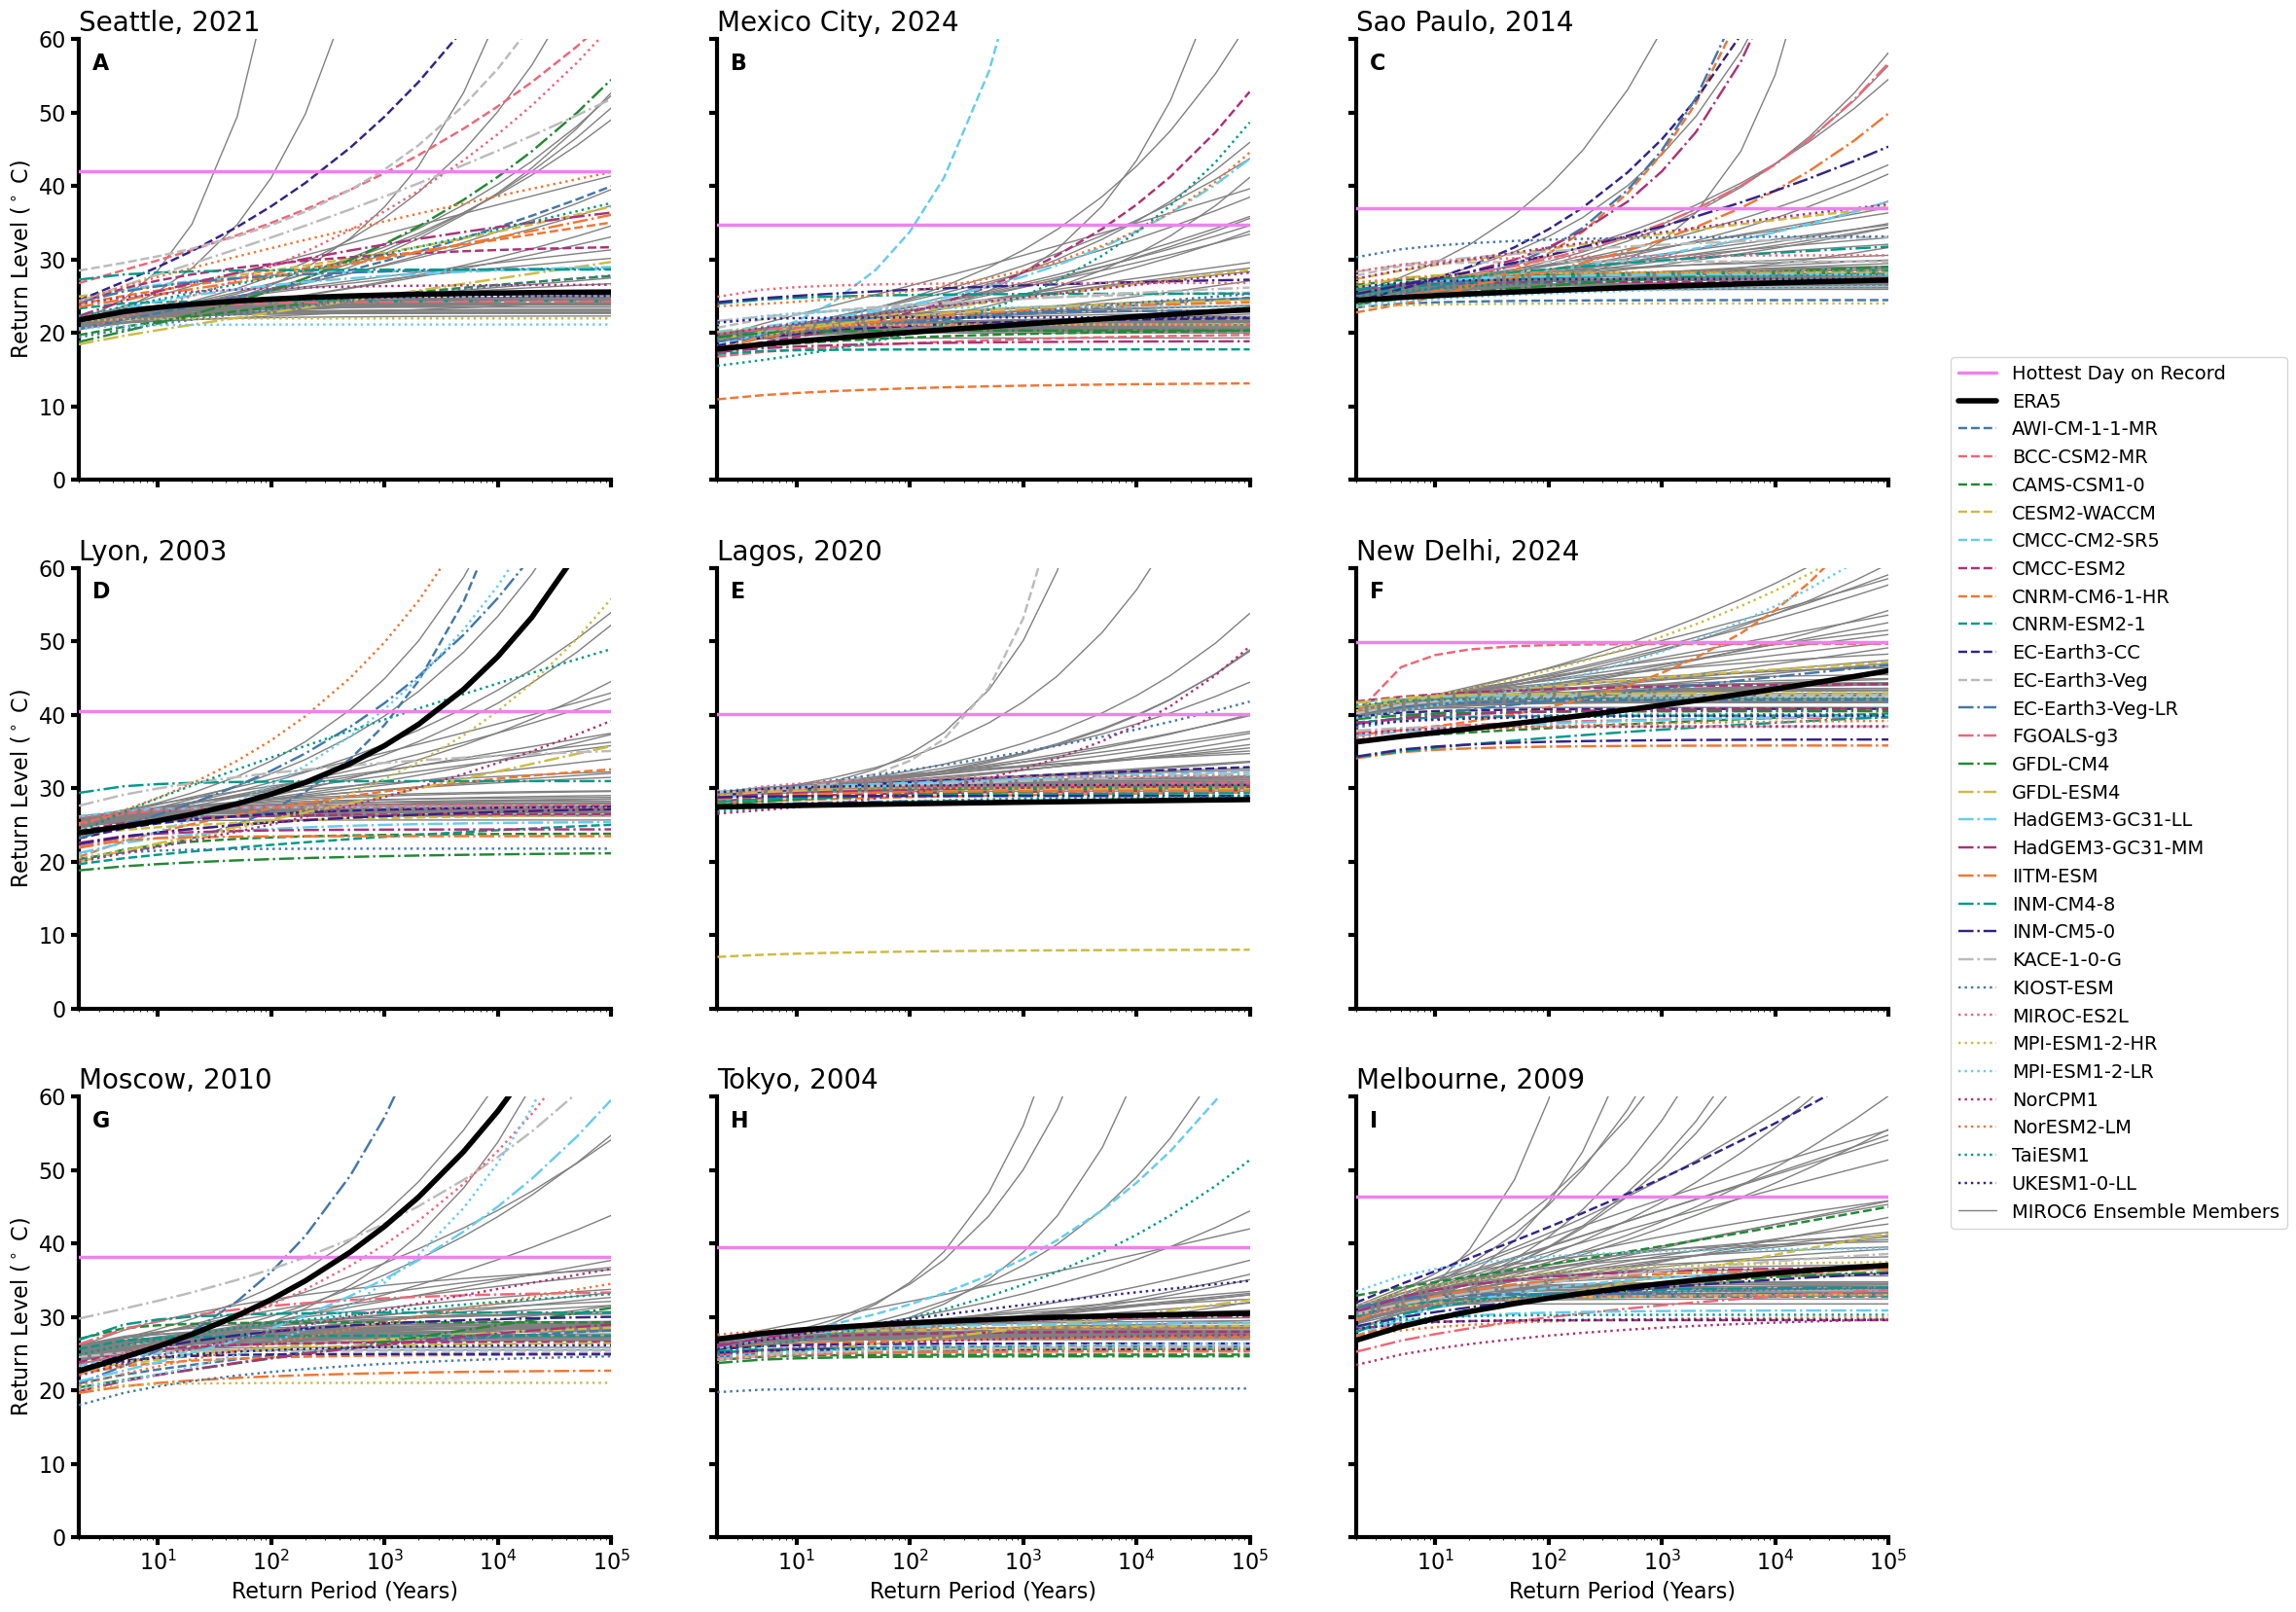

In [24]:
fig, ax = plt.subplots(3, 3, figsize=(24, 20), sharex=True, sharey=True)
titles = {k: ''.join([k, ', ', str(event_info[k]['year'])]) for k in event_info.keys()}

models = list(CMIPConfig.iter_active_models(cmip_variable))

for locx, (a, loc) in enumerate(zip(ax.flatten(), event_info.keys())):
    a.plot([0, 1], [0, 1])
    a.set_title(titles[loc])
    a.set_ylim((0, 60))
    a.set_xlim((2, 1e5))

    a.axhline(event_info[loc]['max_T_raw_obs'], linestyle='solid', linewidth=2.5, color='violet', label='Hottest Day on Record', zorder=100)

    # plot era5
    a.semilogx(return_periods, era5_ret_levels[locx] - 274.15, label='ERA5', linestyle='solid', color='black', linewidth=4, zorder=100)

    for idx, m in enumerate(models):
        color = colors[idx % 10]
        linestyle = linestyles[idx // 10]
        
        a.semilogx(return_periods, return_levels_prim[locx, idx] - 274.15, label=m.name if m.name != 'MIROC6' else None, linestyle=linestyle, linewidth=1.75, color=color, zorder=99)

    for idx in range(np.shape(return_levels_most)[1]):
        a.semilogx(return_periods, return_levels_most[locx, idx] - 274.15, label=f'{model_with_most} Ensemble Members' if idx == 0 else None,
                   linestyle='solid', linewidth=1, color='grey', zorder=1)

ax[0, 0].set_ylabel("Return Level ($^\circ$ C)")
ax[1, 0].set_ylabel("Return Level ($^\circ$ C)")
ax[2, 0].set_ylabel("Return Level ($^\circ$ C)")

ax[2, 0].set_xlabel("Return Period (Years)")
ax[2, 1].set_xlabel("Return Period (Years)")
ax[2, 2].set_xlabel("Return Period (Years)")

ax[1, 2].legend(bbox_to_anchor=(1.1, 1.5), ncols=1, fontsize=14, frameon=True)

labels = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I']
for a, label in zip(ax.flatten(), labels):
    a.text(0.025, 0.97, label, transform=a.transAxes,
           fontsize=16, fontweight='bold', va='top', ha='left')

if save_figs:
    fname = make_figure_filename(f'return_levels_all_{anom_type}_obs_high', 'png', 'figs/analysis')
    fig.savefig(fname, dpi=300, bbox_inches='tight')
    print(f"✍️ Figure saved to: {fname}")

✍️ Figure saved to: figs/analysis/2026-03-25-return_levels_all_raw_era5_annhigh.png


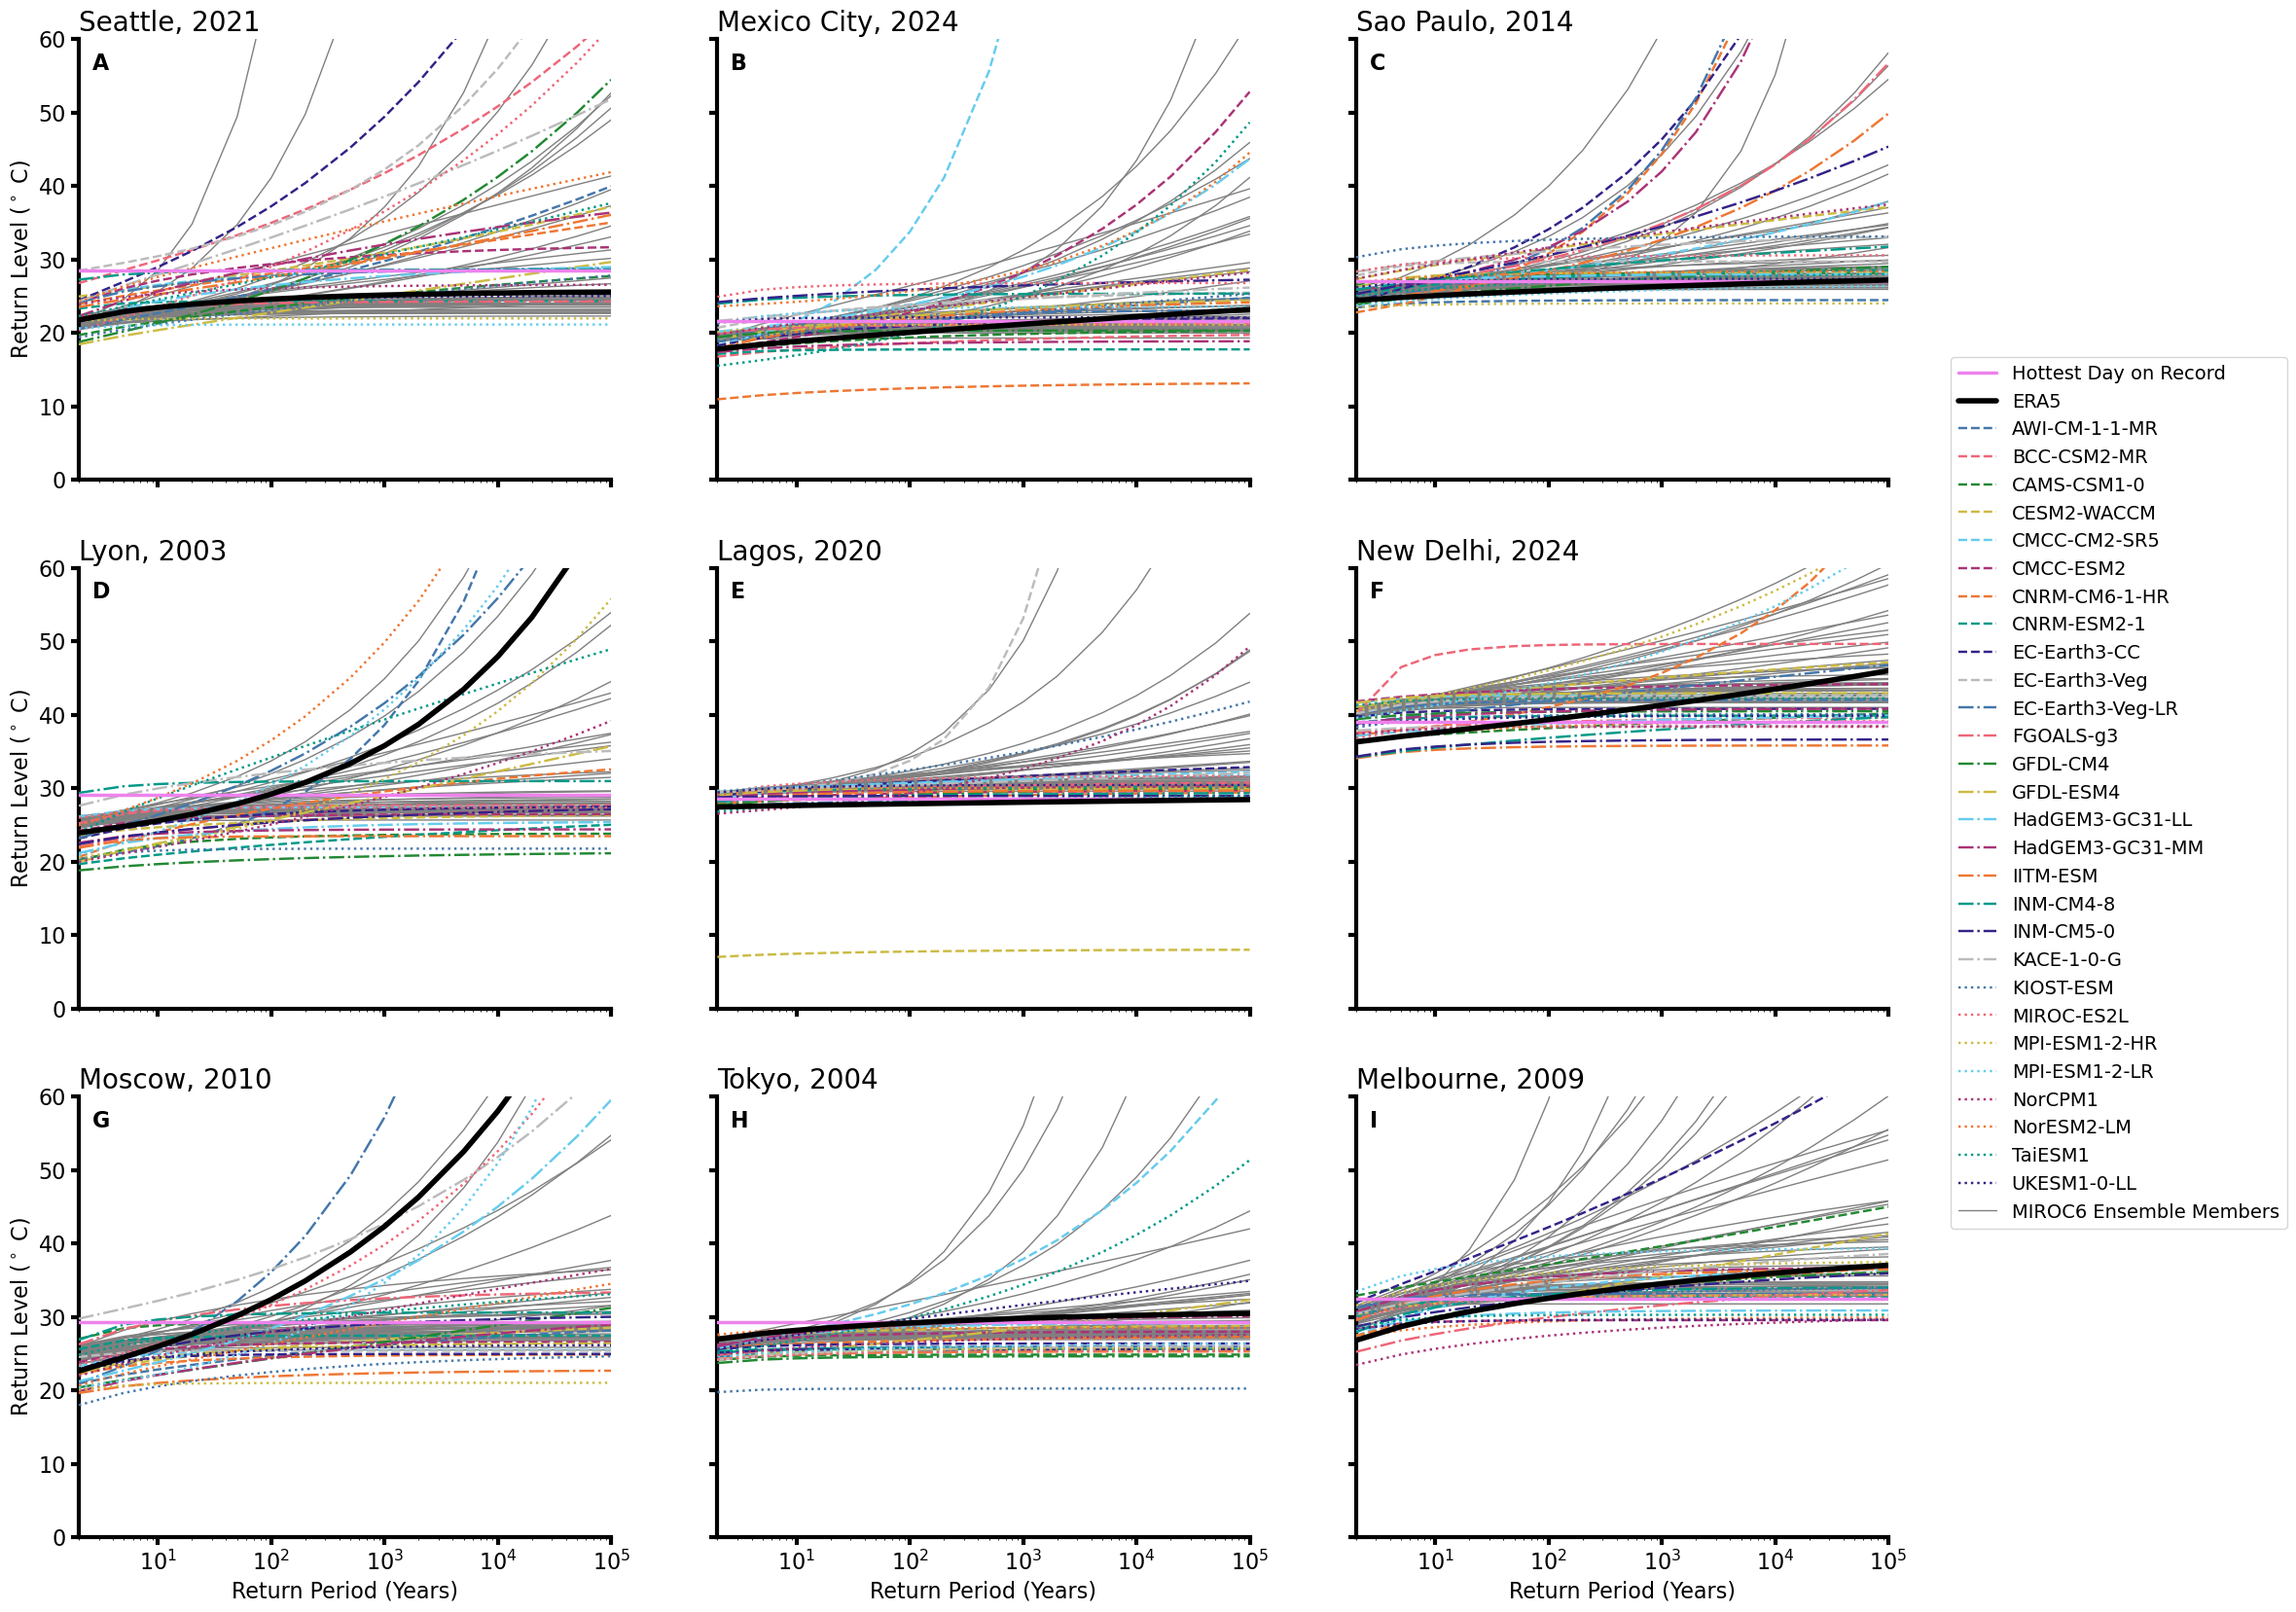

In [25]:
fig, ax = plt.subplots(3, 3, figsize=(24, 20), sharex=True, sharey=True)
titles = {k: ''.join([k, ', ', str(event_info[k]['year'])]) for k in event_info.keys()}

models = list(CMIPConfig.iter_active_models(cmip_variable))

for locx, (a, loc) in enumerate(zip(ax.flatten(), event_info.keys())):
    a.plot([0, 1], [0, 1])
    a.set_title(titles[loc])
    a.set_ylim((0, 60))
    a.set_xlim((2, 1e5))

    a.axhline(era5_max_temp[locx], linestyle='solid', linewidth=2.5, color='violet', label='Hottest Day on Record', zorder=100)

    # plot era5
    a.semilogx(return_periods, era5_ret_levels[locx] - 274.15, label='ERA5', linestyle='solid', color='black', linewidth=4, zorder=100)

    for idx, m in enumerate(models):
        color = colors[idx % 10]
        linestyle = linestyles[idx // 10]
        
        a.semilogx(return_periods, return_levels_prim[locx, idx] - 274.15, label=m.name if m.name != 'MIROC6' else None, linestyle=linestyle, linewidth=1.75, color=color, zorder=99)

    for idx in range(np.shape(return_levels_most)[1]):
        a.semilogx(return_periods, return_levels_most[locx, idx] - 274.15, label=f'{model_with_most} Ensemble Members' if idx == 0 else None,
                   linestyle='solid', linewidth=1, color='grey', zorder=1)

ax[0, 0].set_ylabel("Return Level ($^\circ$ C)")
ax[1, 0].set_ylabel("Return Level ($^\circ$ C)")
ax[2, 0].set_ylabel("Return Level ($^\circ$ C)")

ax[2, 0].set_xlabel("Return Period (Years)")
ax[2, 1].set_xlabel("Return Period (Years)")
ax[2, 2].set_xlabel("Return Period (Years)")

ax[1, 2].legend(bbox_to_anchor=(1.1, 1.5), ncols=1, fontsize=14, frameon=True)

labels = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I']
for a, label in zip(ax.flatten(), labels):
    a.text(0.025, 0.97, label, transform=a.transAxes,
           fontsize=16, fontweight='bold', va='top', ha='left')

if save_figs:
    fname = make_figure_filename(f'return_levels_all_{anom_type}_era5_annhigh', 'png', 'figs/analysis')
    fig.savefig(fname, dpi=300, bbox_inches='tight')
    print(f"✍️ Figure saved to: {fname}")

Note to self (3/24/2026): I'm proceeding with the observed max as opposed to the hottest day of the year with the event. I think the observed high is the better reference point, though I understand that the values are a little inconsistent (annual max pulled from daily mean is not the same as hottest day becauase the daily mean smooths over the diurnal cycle).

# Plot 2: 100-year heat wave trend
The idea is to compute the 100-year return level from 1979 -> 2024 using the GEV fits that we have. Should be relatively easy. (Though you never know...)

In [29]:
np.shape(return_levels_most)

(9, 50, 15)

In [50]:
# set global attributes of analysis
EVENT_PERIOD = 10.  # set return period
years = np.arange(1979, 2025, 1)  # years to analyze

# empty arrays to fill later
event_level_trend_most = np.zeros([
    *np.shape(return_levels_most)[:-1], len(years)
])

event_level_trend_prim = np.zeros([
    *np.shape(return_levels_prim)[:-1], len(years)
])

Most members analysis.

In [51]:
# open dataset
ds = xr.open_dataset(allmems_filepaths[0], engine='netcdf4')

for edx, loc in enumerate(event_info.keys()):
    print(f"\n 🔥 Working on {loc}...")

    for idx, mem in enumerate(ds.member_id.values):
        print(f"    ⚒️ Working on member: {mem}")

        # do this for each location
        tmp_ds = ds.sel(member_id=mem)
        tmp_ds = tmp_ds.sel(lat=event_info[loc]['lat'], lon=event_info[loc]['lon'], method='nearest')

        # compute offset of climatatological temps in model vs era5
        offset = recenter_model_to_era5(event_info[loc], ds_era5_temps,
                                        cmip_model_name=model_with_most, member_id=mem)

        # carry out calculations for both nonstationary and stationary cases
        if fit == 'nonstat':
            # extract model variables
            m_loc, m_loc_trend = tmp_ds[f'loc_{data_type}'].values.flatten(), tmp_ds[f'loc_t_{data_type}'].values.flatten() 
            m_scale, m_scale_trend = tmp_ds[f'scale_{data_type}'].values.flatten(), tmp_ds[f'scale_t_{data_type}'].values.flatten() 
            m_shape, m_shape_trend = tmp_ds[f'shape_{data_type}'].values.flatten(), tmp_ds[f'shape_t_{data_type}'].values.flatten() 

            if (np.isnan(m_loc) or np.isnan(m_loc_trend)
                or np.isnan(m_scale) or np.isnan(m_scale_trend)
                or np.isnan(m_shape) or np.isnan(m_shape_trend)):
                warnings.warn(f"Member {mem} skipped for event in {loc} because of nans")
                event_level_trend_most[edx, idx] = np.array([np.nan] * len(years))

            else:
                event_level_trend_most[edx, idx] = np.array([
                    get_return_level(1/EVENT_PERIOD,
                                     m_loc + m_loc_trend * (yr - TMIN) / (len(tmp_ds.year.values) - TMIN),
                                     m_scale + m_scale_trend * (yr - TMIN) / (len(tmp_ds.year.values) - TMIN),
                                     m_shape + m_shape_trend * (yr - TMIN) / (len(tmp_ds.year.values) - TMIN))[0] + offset - 274.15
                    for yr in years
                ])

        else:
            import warnings
            warnings.warn("Warning: `stat` not implemented yet or stupid model. Skipping.")


 🔥 Working on Seattle...
    ⚒️ Working on member: MIROC6_r10i1p1f1
    ⚒️ Working on member: MIROC6_r8i1p1f1
    ⚒️ Working on member: MIROC6_r11i1p1f1
    ⚒️ Working on member: MIROC6_r9i1p1f1
    ⚒️ Working on member: MIROC6_r12i1p1f1
    ⚒️ Working on member: MIROC6_r13i1p1f1
    ⚒️ Working on member: MIROC6_r14i1p1f1
    ⚒️ Working on member: MIROC6_r15i1p1f1
    ⚒️ Working on member: MIROC6_r16i1p1f1
    ⚒️ Working on member: MIROC6_r17i1p1f1
    ⚒️ Working on member: MIROC6_r18i1p1f1
    ⚒️ Working on member: MIROC6_r19i1p1f1
    ⚒️ Working on member: MIROC6_r1i1p1f1
    ⚒️ Working on member: MIROC6_r20i1p1f1
    ⚒️ Working on member: MIROC6_r21i1p1f1
    ⚒️ Working on member: MIROC6_r22i1p1f1
    ⚒️ Working on member: MIROC6_r23i1p1f1
    ⚒️ Working on member: MIROC6_r24i1p1f1
    ⚒️ Working on member: MIROC6_r25i1p1f1
    ⚒️ Working on member: MIROC6_r26i1p1f1
    ⚒️ Working on member: MIROC6_r27i1p1f1
    ⚒️ Working on member: MIROC6_r28i1p1f1
    ⚒️ Working on member: MIROC

/scratch/local/jobs/47619552/ipykernel_1928717/3260403412.py:28: UserWarning: Member MIROC6_r32i1p1f1 skipped for event in Sao Paulo because of nans
  warnings.warn(f"Member {mem} skipped for event in {loc} because of nans")


    ⚒️ Working on member: MIROC6_r34i1p1f1
    ⚒️ Working on member: MIROC6_r35i1p1f1
    ⚒️ Working on member: MIROC6_r36i1p1f1
    ⚒️ Working on member: MIROC6_r37i1p1f1
    ⚒️ Working on member: MIROC6_r38i1p1f1
    ⚒️ Working on member: MIROC6_r39i1p1f1
    ⚒️ Working on member: MIROC6_r3i1p1f1
    ⚒️ Working on member: MIROC6_r40i1p1f1
    ⚒️ Working on member: MIROC6_r41i1p1f1
    ⚒️ Working on member: MIROC6_r42i1p1f1
    ⚒️ Working on member: MIROC6_r43i1p1f1
    ⚒️ Working on member: MIROC6_r44i1p1f1
    ⚒️ Working on member: MIROC6_r45i1p1f1
    ⚒️ Working on member: MIROC6_r46i1p1f1
    ⚒️ Working on member: MIROC6_r47i1p1f1
    ⚒️ Working on member: MIROC6_r48i1p1f1
    ⚒️ Working on member: MIROC6_r49i1p1f1
    ⚒️ Working on member: MIROC6_r4i1p1f1
    ⚒️ Working on member: MIROC6_r50i1p1f1
    ⚒️ Working on member: MIROC6_r5i1p1f1
    ⚒️ Working on member: MIROC6_r6i1p1f1
    ⚒️ Working on member: MIROC6_r7i1p1f1

 🔥 Working on Lyon...
    ⚒️ Working on member: MIROC6_r10

In [52]:
# loop through models 
for edx, loc in enumerate(event_info.keys()):
    print(f"\n 🔥 Working on {loc}")
    
    for (idx, m) in enumerate(list(CMIPConfig.iter_active_models(cmip_variable))):
        print(f"    ⚒️ Working on {m.name}...")

        # open dataset
        tmp_ds = xr.open_dataset(
            modelname_filepath_matcher[m.name]
        )

        # do this for each location
        tmp_ds = tmp_ds.sel(lat=event_info[loc]['lat'], lon=event_info[loc]['lon'], method='nearest')

        # compute offset of climatatological temps in model vs era5
        offset = recenter_model_to_era5(event_info[loc], ds_era5_temps,
                                        cmip_model_name=m.name, member_id=m.primary_member)

        # carry out calculations for both nonstationary and stationary cases
        if fit == 'nonstat':
            # extract model variables
            m_loc, m_loc_trend = tmp_ds[f'loc_{data_type}'].values.flatten(), tmp_ds[f'loc_t_{data_type}'].values.flatten() 
            m_scale, m_scale_trend = tmp_ds[f'scale_{data_type}'].values.flatten(), tmp_ds[f'scale_t_{data_type}'].values.flatten() 
            m_shape, m_shape_trend = tmp_ds[f'shape_{data_type}'].values.flatten(), tmp_ds[f'shape_t_{data_type}'].values.flatten() 

            if (np.isnan(m_loc) or np.isnan(m_loc_trend)
                or np.isnan(m_scale) or np.isnan(m_scale_trend)
                or np.isnan(m_shape) or np.isnan(m_shape_trend)):
                warnings.warn(f"Member {mem} skipped for event in {loc} because of nans")
                event_level_trend_prim[edx, idx] = np.array([np.nan] * len(years))

            else:
                # threshold check on scale parameter 
                if m_scale < 1e-2:
                    warnings.warn(f"Model {m.name} skipped for event in {loc} because the scale parameter is unreasonably small")
                    return_levels_prim[edx, idx] = np.array([np.nan] * len(return_probs))

                else:
                    event_level_trend_prim[edx, idx] = np.array([
                        get_return_level(1/EVENT_PERIOD,
                                        m_loc + m_loc_trend * (yr - TMIN) / (len(tmp_ds.year.values) - TMIN),
                                        m_scale + m_scale_trend * (yr - TMIN) / (len(tmp_ds.year.values) - TMIN),
                                        m_shape + m_shape_trend * (yr - TMIN) / (len(tmp_ds.year.values) - TMIN))[0] + offset - 274.15
                        for yr in years
                    ])

        else:
            import warnings
            warnings.warn("Warning: `stat` not implemented yet or stupid model. Skipping.")

        tmp_ds.close()


 🔥 Working on Seattle
    ⚒️ Working on AWI-CM-1-1-MR...


    ⚒️ Working on BCC-CSM2-MR...
    ⚒️ Working on CAMS-CSM1-0...
    ⚒️ Working on CESM2-WACCM...
    ⚒️ Working on CMCC-CM2-SR5...
    ⚒️ Working on CMCC-ESM2...
    ⚒️ Working on CNRM-CM6-1-HR...
    ⚒️ Working on CNRM-ESM2-1...
    ⚒️ Working on EC-Earth3-CC...
    ⚒️ Working on EC-Earth3-Veg...
    ⚒️ Working on EC-Earth3-Veg-LR...
    ⚒️ Working on FGOALS-g3...
    ⚒️ Working on GFDL-CM4...
    ⚒️ Working on GFDL-ESM4...
    ⚒️ Working on HadGEM3-GC31-LL...
    ⚒️ Working on HadGEM3-GC31-MM...
    ⚒️ Working on IITM-ESM...
    ⚒️ Working on INM-CM4-8...
    ⚒️ Working on INM-CM5-0...
    ⚒️ Working on KACE-1-0-G...


/scratch/local/jobs/47619552/ipykernel_1928717/417572300.py:30: UserWarning: Member MIROC6_r7i1p1f1 skipped for event in Seattle because of nans
  warnings.warn(f"Member {mem} skipped for event in {loc} because of nans")


    ⚒️ Working on KIOST-ESM...
    ⚒️ Working on MIROC-ES2L...
    ⚒️ Working on MIROC6...
    ⚒️ Working on MPI-ESM1-2-HR...
    ⚒️ Working on MPI-ESM1-2-LR...
    ⚒️ Working on NorCPM1...
    ⚒️ Working on NorESM2-LM...
    ⚒️ Working on TaiESM1...
    ⚒️ Working on UKESM1-0-LL...

 🔥 Working on Mexico City
    ⚒️ Working on AWI-CM-1-1-MR...
    ⚒️ Working on BCC-CSM2-MR...
    ⚒️ Working on CAMS-CSM1-0...
    ⚒️ Working on CESM2-WACCM...
    ⚒️ Working on CMCC-CM2-SR5...
    ⚒️ Working on CMCC-ESM2...
    ⚒️ Working on CNRM-CM6-1-HR...
    ⚒️ Working on CNRM-ESM2-1...
    ⚒️ Working on EC-Earth3-CC...
    ⚒️ Working on EC-Earth3-Veg...
    ⚒️ Working on EC-Earth3-Veg-LR...
    ⚒️ Working on FGOALS-g3...
    ⚒️ Working on GFDL-CM4...
    ⚒️ Working on GFDL-ESM4...
    ⚒️ Working on HadGEM3-GC31-LL...
    ⚒️ Working on HadGEM3-GC31-MM...
    ⚒️ Working on IITM-ESM...
    ⚒️ Working on INM-CM4-8...
    ⚒️ Working on INM-CM5-0...
    ⚒️ Working on KACE-1-0-G...
    ⚒️ Working on KIOST-E

/scratch/local/jobs/47619552/ipykernel_1928717/417572300.py:30: UserWarning: Member MIROC6_r7i1p1f1 skipped for event in Lyon because of nans
  warnings.warn(f"Member {mem} skipped for event in {loc} because of nans")


...

    ⚒️ Working on CMCC-CM2-SR5...
    ⚒️ Working on CMCC-ESM2...
    ⚒️ Working on CNRM-CM6-1-HR...
    ⚒️ Working on CNRM-ESM2-1...
    ⚒️ Working on EC-Earth3-CC...
    ⚒️ Working on EC-Earth3-Veg...


/scratch/local/jobs/47619552/ipykernel_1928717/417572300.py:36: UserWarning: Model EC-Earth3-Veg skipped for event in Tokyo because the scale parameter is unreasonably small
  warnings.warn(f"Model {m.name} skipped for event in {loc} because the scale parameter is unreasonably small")


    ⚒️ Working on EC-Earth3-Veg-LR...
    ⚒️ Working on FGOALS-g3...
    ⚒️ Working on GFDL-CM4...
    ⚒️ Working on GFDL-ESM4...
    ⚒️ Working on HadGEM3-GC31-LL...
    ⚒️ Working on HadGEM3-GC31-MM...
    ⚒️ Working on IITM-ESM...
    ⚒️ Working on INM-CM4-8...
    ⚒️ Working on INM-CM5-0...
    ⚒️ Working on KACE-1-0-G...
    ⚒️ Working on KIOST-ESM...
    ⚒️ Working on MIROC-ES2L...
    ⚒️ Working on MIROC6...
    ⚒️ Working on MPI-ESM1-2-HR...
    ⚒️ Working on MPI-ESM1-2-LR...
    ⚒️ Working on NorCPM1...
    ⚒️ Working on NorESM2-LM...
    ⚒️ Working on TaiESM1...
    ⚒️ Working on UKESM1-0-LL...

 🔥 Working on Melbourne
    ⚒️ Working on AWI-CM-1-1-MR...
    ⚒️ Working on BCC-CSM2-MR...


/scratch/local/jobs/47619552/ipykernel_1928717/417572300.py:30: UserWarning: Member MIROC6_r7i1p1f1 skipped for event in Melbourne because of nans
  warnings.warn(f"Member {mem} skipped for event in {loc} because of nans")


    ⚒️ Working on CAMS-CSM1-0...
    ⚒️ Working on CESM2-WACCM...
    ⚒️ Working on CMCC-CM2-SR5...
    ⚒️ Working on CMCC-ESM2...
    ⚒️ Working on CNRM-CM6-1-HR...
    ⚒️ Working on CNRM-ESM2-1...
    ⚒️ Working on EC-Earth3-CC...
    ⚒️ Working on EC-Earth3-Veg...
    ⚒️ Working on EC-Earth3-Veg-LR...
    ⚒️ Working on FGOALS-g3...
    ⚒️ Working on GFDL-CM4...
    ⚒️ Working on GFDL-ESM4...
    ⚒️ Working on HadGEM3-GC31-LL...
    ⚒️ Working on HadGEM3-GC31-MM...
    ⚒️ Working on IITM-ESM...
    ⚒️ Working on INM-CM4-8...
    ⚒️ Working on INM-CM5-0...
    ⚒️ Working on KACE-1-0-G...
    ⚒️ Working on KIOST-ESM...
    ⚒️ Working on MIROC-ES2L...
    ⚒️ Working on MIROC6...
    ⚒️ Working on MPI-ESM1-2-HR...
    ⚒️ Working on MPI-ESM1-2-LR...
    ⚒️ Working on NorCPM1...
    ⚒️ Working on NorESM2-LM...
    ⚒️ Working on TaiESM1...
    ⚒️ Working on UKESM1-0-LL...


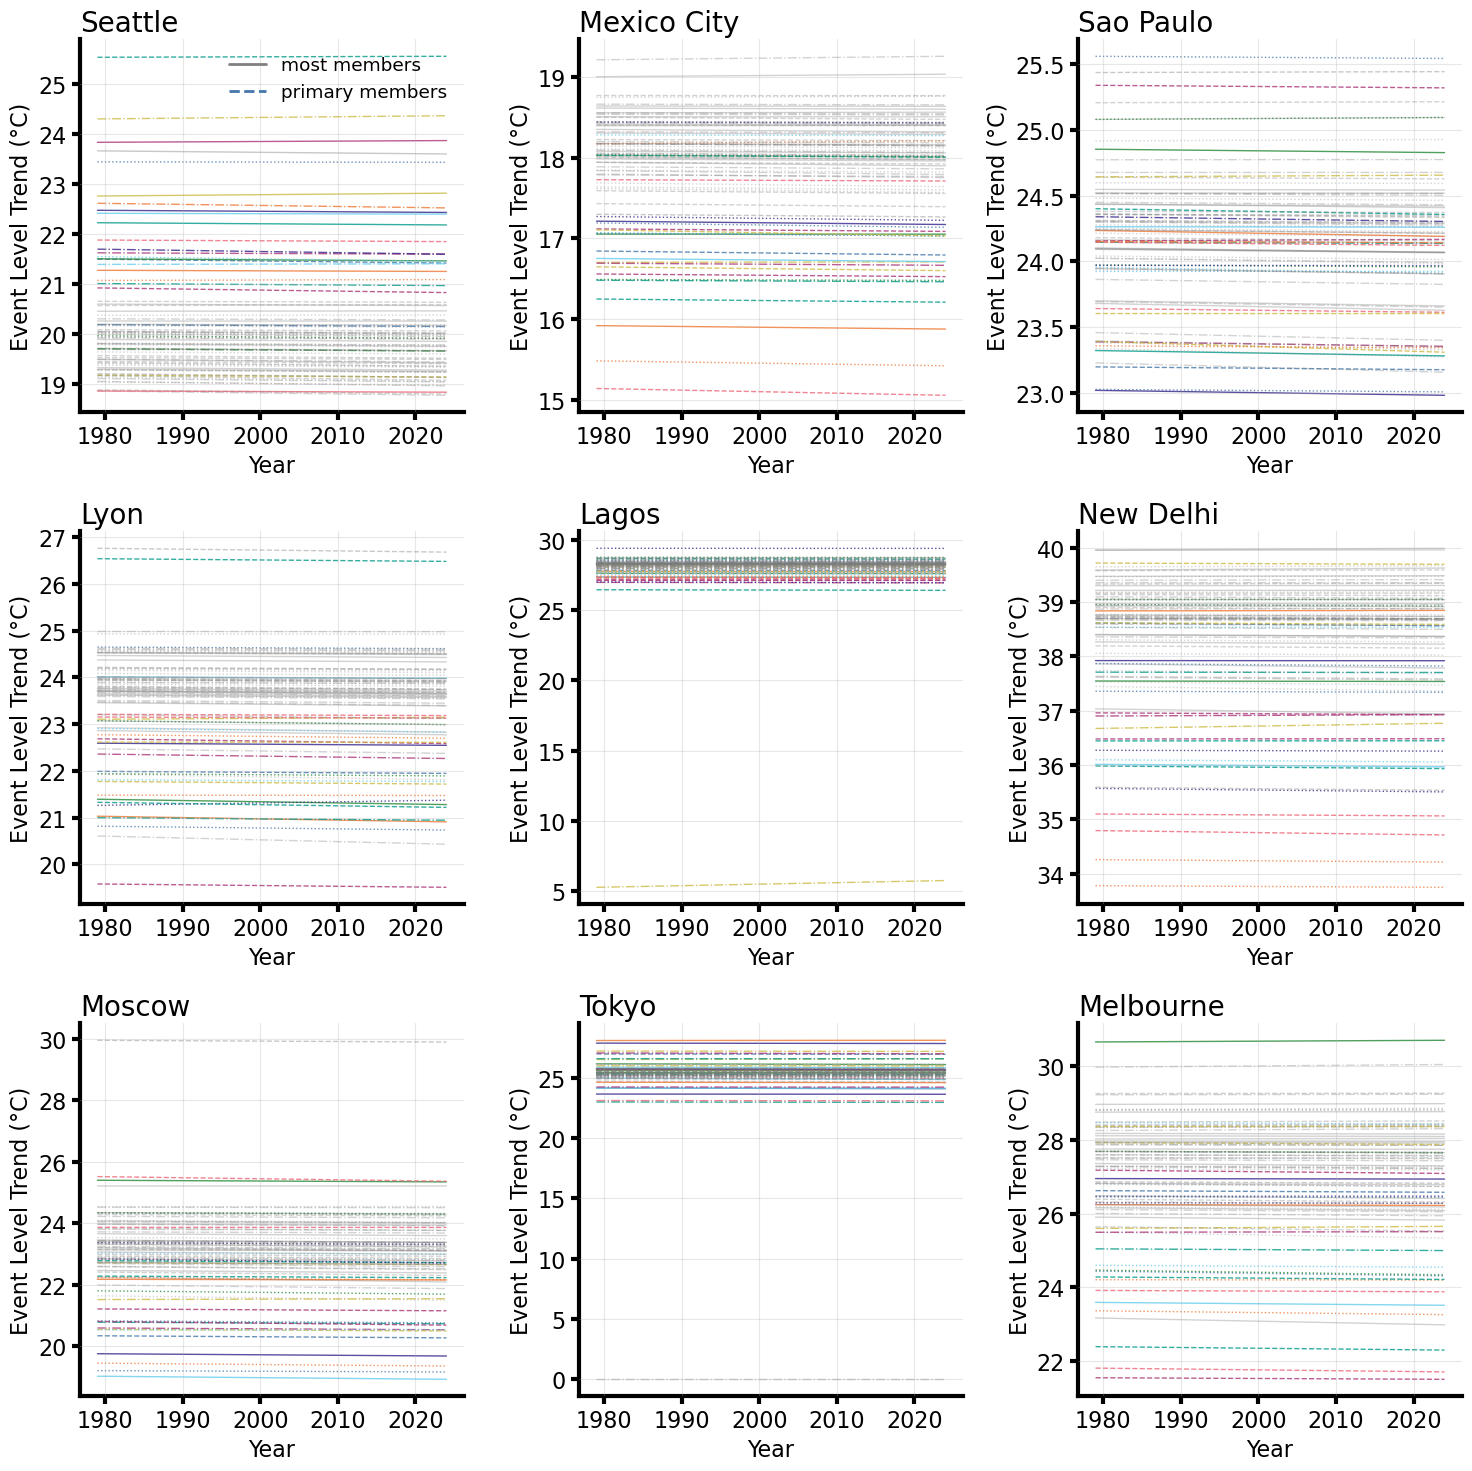

In [ ]:
# Plot event_level_trend for each location and each member
fig, axes = plt.subplots(3, 3, figsize=(15, 15))
axes = axes.flatten()

n_members_most = event_level_trend_most.shape[1]
n_members_prim = event_level_trend_prim.shape[1]

for edx, loc in enumerate(event_info.keys()):
    ax = axes[edx]
    for idx in range(max(n_members_most, n_members_prim)):
        if idx < n_members_most:
            trend_most = event_level_trend_most[edx, idx, :]
            if not np.all(np.isnan(trend_most)):
                ax.plot(years, trend_most, alpha=0.35, color='grey', linewidth=1)

        if idx < n_members_prim:
            trend_prim = event_level_trend_prim[edx, idx, :]
            if not np.all(np.isnan(trend_prim)):
                c = colors[idx % len(colors)]
                ax.plot(years, trend_prim, alpha=0.8, color=c, linewidth=1)

    ax.set_title(f"{loc}")
    ax.set_xlabel("Year")
    ax.set_ylabel("Event Level Trend (°C)")
    ax.grid(True, alpha=0.3)

# add legend for the first subplot only
axes[0].plot([], [], color='grey', linewidth=2, label='most members')
axes[0].plot([], [], color=colors[0], linewidth=2, label='primary members')
axes[0].legend(loc='best', fontsize='small')

plt.tight_layout()
#if save_figs:
    #fig.savefig(make_figure_filename("event_level_trends_most_and_prim_members.png"), dpi=300, bbox_inches='tight')
plt.show()